# 영화 추천 시스템

### Movie Recommendation Work Flow

1. 라이브러리 불러오기
2. 데이터 로딩
3. 데이터 구조 확인
4. 데이터 병합
5. 평점 분포 분석
6. 영화별 평점 개수 생성 - Feature Engineering
7. 영화별 평균 평점 생성 - Feature Engineering
8. 인기 영화 추천
9. 장르 데이터 확인 - 검색 데이터, 신규회원 정보 입력
10. 장르 벡터화
11. 코사인 유사도 계산
12. 콘텐츠 기반 추천 함수 작성
13. 추천 결과 확인

###  ratings.csv
- 인기 영화 추천  : Popularity Recommendation Model
- 영화별 평점 개수, 영화별 평균 평점 => 인기 영화 추천

###  movies.csv
- 영화 장르 추천  : Content-Based Recommendation Model, Collaborative Recommendation Model
- 영화 장르 확인 및 변환(벡터화, One-Hot Encoding)
  => 코사인 유사도(영화별 평점 개수, 영화별 평균 평점 사용)
  => 유사 영화 추천  

## 1. 라이브러리 불러오기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [3]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 3. 데이터 구조 확인

In [4]:
# 1. ratings, movies 구조 확인
print(ratings.shape)
print(movies.shape)

(100836, 4)
(9742, 3)


In [5]:
# 2. 컬럼 확인
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


## 4. 결측치 & 중복 확인

In [ ]:
# 결측치 확인
print(ratings.isnull().sum())
print(movies.isnull().sum())

In [7]:
# 중복 확인
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [9]:
# 동일한 사용자가 동일한 영화에 중복해서 평점을 주었는지 확인
print(ratings.duplicated(subset=["userId", "movieId"]).sum())

0


## 5. ratings + movies 병합

In [10]:
movie_ratings = movies.merge(ratings, on="movieId", how="left")
print(movie_ratings.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating     timestamp  
0     1.0     4.0  9.649827e+08  
1     5.0     4.0  8.474350e+08  
2     7.0     4.5  1.106636e+09  
3    15.0     2.5  1.510578e+09  
4    17.0     4.5  1.305696e+09  


## 6. 전체 평점 분포

In [15]:
ratings_count = ratings["rating"].value_counts().sort_index()
print(ratings_count)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


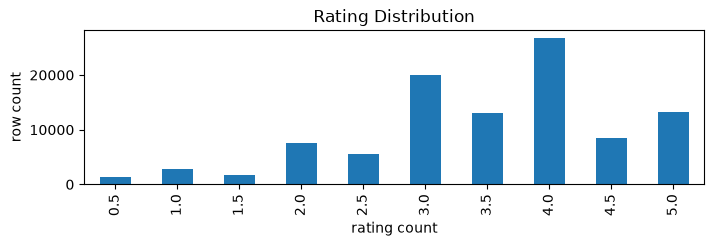

In [19]:
ratings_count.plot(kind="bar", figsize=(8,2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

## 7. 사용자별 평점 개수

In [26]:
user_rating_count = (ratings.groupby("userId").size().reset_index(name="user_rating_count"))
print(user_rating_count)

     userId  user_rating_count
0         1                232
1         2                 29
2         3                 39
3         4                216
4         5                 44
..      ...                ...
605     606               1115
606     607                187
607     608                831
608     609                 37
609     610               1302

[610 rows x 2 columns]


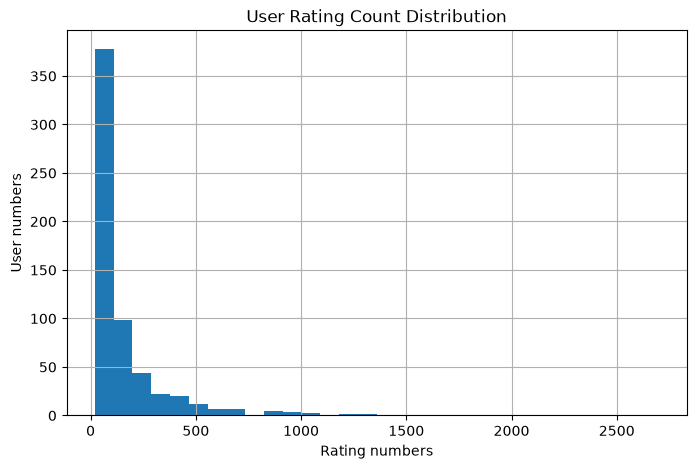

In [28]:
# 분포 확인
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,5))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating numbers")
plt.ylabel("User numbers")
plt.show()

## 8. 영화별 평점 개수 Feature 생성

In [32]:
movie_rating_count = (ratings.groupby("movieId").size().reset_index(name="movie_rating_count"))
print(movie_rating_count)

      movieId  movie_rating_count
0           1                 215
1           2                 110
2           3                  52
3           4                   7
4           5                  49
...       ...                 ...
9719   193581                   1
9720   193583                   1
9721   193585                   1
9722   193587                   1
9723   193609                   1

[9724 rows x 2 columns]


In [34]:
# 영화별 평점 개수(movie_rating_count) + 영화(movies) 병합
movie_rating_count = movies.merge(movie_rating_count, on="movieId")
print(movie_rating_count)

      movieId                                      title  \
0           1                           Toy Story (1995)   
1           2                             Jumanji (1995)   
2           3                    Grumpier Old Men (1995)   
3           4                   Waiting to Exhale (1995)   
4           5         Father of the Bride Part II (1995)   
...       ...                                        ...   
9719   193581  Black Butler: Book of the Atlantic (2017)   
9720   193583               No Game No Life: Zero (2017)   
9721   193585                               Flint (2017)   
9722   193587        Bungo Stray Dogs: Dead Apple (2018)   
9723   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  movie_rating_count  
0     Adventure|Animation|Children|Comedy|Fantasy                 215  
1                      Adventure|Children|Fantasy                 110  
2                                  Comedy|Romance              

In [36]:
# 평점 개수를 기준으로 인기 영화 추천
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False)
print(popular_movies.head(10))

      movieId                                      title  \
314       356                        Forrest Gump (1994)   
277       318           Shawshank Redemption, The (1994)   
257       296                        Pulp Fiction (1994)   
510       593           Silence of the Lambs, The (1991)   
1938     2571                         Matrix, The (1999)   
224       260  Star Wars: Episode IV - A New Hope (1977)   
418       480                       Jurassic Park (1993)   
97        110                          Braveheart (1995)   
507       589          Terminator 2: Judgment Day (1991)   
461       527                    Schindler's List (1993)   

                                genres  movie_rating_count  
314           Comedy|Drama|Romance|War                 329  
277                        Crime|Drama                 317  
257        Comedy|Crime|Drama|Thriller                 307  
510              Crime|Horror|Thriller                 279  
1938            Action|Sci-Fi|Thri

## 9. 영화별 평균 평점 Feature 생성

In [38]:
movie_rating_mean = (ratings.groupby("movieId")["rating"].mean().reset_index(name="movie_rating_mean"))
print(movie_rating_mean)

      movieId  movie_rating_mean
0           1           3.920930
1           2           3.431818
2           3           3.259615
3           4           2.357143
4           5           3.071429
...       ...                ...
9719   193581           4.000000
9720   193583           3.500000
9721   193585           3.500000
9722   193587           3.500000
9723   193609           4.000000

[9724 rows x 2 columns]


In [39]:
# movie_stats = 평점 개수 + 평균 평점 + 영화 정보
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId")
print(movie_stats.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy                 215   
1                   Adventure|Children|Fantasy                 110   
2                               Comedy|Romance                  52   
3                         Comedy|Drama|Romance                   7   
4                                       Comedy                  49   

   movie_rating_mean  
0           3.920930  
1           3.431818  
2           3.259615  
3           2.357143  
4           3.071429  


In [42]:
# 평점이 높은 영화 정렬
high_rating_movies = movie_stats.sort_values("movie_rating_mean", ascending=False)
print(high_rating_movies)

      movieId                                  title  \
7638    88448  Paper Birds (Pájaros de papel) (2010)   
8089   100556             Act of Killing, The (2012)   
9065   143031                        Jump In! (2007)   
9076   143511                           Human (2015)   
9078   143559                    L.A. Slasher (2015)   
...       ...                                    ...   
9253   157172  Wizards of the Lost Kingdom II (1989)   
7536    85334           Hard Ticket to Hawaii (1987)   
6486    53453   Starcrash (a.k.a. Star Crash) (1978)   
5200     8494             Cincinnati Kid, The (1965)   
7145    71810                     Legionnaire (1998)   

                               genres  movie_rating_count  movie_rating_mean  
7638                     Comedy|Drama                   1                5.0  
8089                      Documentary                   1                5.0  
9065             Comedy|Drama|Romance                   1                5.0  
9076       

In [41]:
# (1순위)평점 개수, (2순위)평균 평점이 높은 영화 정렬
high_rating_movies2 = movie_stats.sort_values(["movie_rating_count", "movie_rating_mean"], ascending=False)
print(high_rating_movies2)

      movieId                             title                       genres  \
314       356               Forrest Gump (1994)     Comedy|Drama|Romance|War   
277       318  Shawshank Redemption, The (1994)                  Crime|Drama   
257       296               Pulp Fiction (1994)  Comedy|Crime|Drama|Thriller   
510       593  Silence of the Lambs, The (1991)        Crime|Horror|Thriller   
1938     2571                Matrix, The (1999)       Action|Sci-Fi|Thriller   
...       ...                               ...                          ...   
9401   165645                Bad Santa 2 (2016)                       Comedy   
9426   167296                   Iron Man (1931)                        Drama   
9540   173307    The Gracefield Incident (2015)         Action|Horror|Sci-Fi   
9572   175475            The Emoji Movie (2017)    Animation|Children|Comedy   
9675   184641   Fullmetal Alchemist 2018 (2017)     Action|Adventure|Fantasy   

      movie_rating_count  movie_rating_

In [59]:
# 기준 설정(1)
# 평가수(movie_rating_count)가 30개 이상인 영화를 기준
qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= 30]
print(qualified_movie.head(10))

    movieId                               title  \
0         1                    Toy Story (1995)   
1         2                      Jumanji (1995)   
2         3             Grumpier Old Men (1995)   
4         5  Father of the Bride Part II (1995)   
5         6                         Heat (1995)   
6         7                      Sabrina (1995)   
9        10                    GoldenEye (1995)   
10       11      American President, The (1995)   
15       16                       Casino (1995)   
16       17        Sense and Sensibility (1995)   

                                         genres  movie_rating_count  \
0   Adventure|Animation|Children|Comedy|Fantasy                 215   
1                    Adventure|Children|Fantasy                 110   
2                                Comedy|Romance                  52   
4                                        Comedy                  49   
5                         Action|Crime|Thriller                 102   
6           

In [56]:
# 기준 설정(2)
# 분위수 0.75 => 25%, 상위 25%에 해당하는 영화만 출력
# min_rating_count = movie_stats["movie_rating_count"].quantile(0.95)
# qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= min_rating_count]
# print(qualified_movie)

## 10. 인기 영화 추천 함수

In [65]:
def recommend_popular_movie(top_n):
    result = (
        qualified_movie.sort_values("movie_rating_mean", ascending=False).head(top_n)
    )

    return result[
        [
            "movieId",
            "title",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ]

In [67]:
# 인기있는 영화 Top10
recommend_popular_movie(20)

,movieId,title,movie_rating_count,movie_rating_mean
277,318,"Shawshank Redemption, The (1994)",317,4.429022
905,1204,Lawrence of Arabia (1962),45,4.300000
659,858,"Godfather, The (1972)",192,4.289062
2224,2959,Fight Club (1999),218,4.272936
974,1276,Cool Hand Luke (1967),57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041
686,904,Rear Window (1954),84,4.261905
921,1221,"Godfather: Part II, The (1974)",129,4.259690
6298,48516,"Departed, The (2006)",107,4.252336
965,1267,"Manchurian Candidate, The (1962)",30,4.250000


## 11. 장르 데이터 이해

In [68]:
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 12. 장르 One-Hot Encoding

In [74]:
# str.get_dummies()
genre_feature = movies["genres"].str.get_dummies(sep="|")
print(genre_feature)

      (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
0                      0       0          1          1         1       1   
1                      0       0          1          0         1       0   
2                      0       0          0          0         0       1   
3                      0       0          0          0         0       1   
4                      0       0          0          0         0       1   
...                  ...     ...        ...        ...       ...     ...   
9737                   0       1          0          1         0       1   
9738                   0       0          0          1         0       1   
9739                   0       0          0          0         0       0   
9740                   0       1          0          1         0       0   
9741                   0       0          0          0         0       1   

      Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical  \
0        

In [73]:
# movies에 genre_feature 컬럼 추가 - concat
movie_features = pd.concat(
    [
        movies[["movieId", "title", "genres"]],
        genre_feature
    ],
    axis=1
)
print(movie_features.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  (no genres listed)  Action  \
0  Adventure|Animation|Children|Comedy|Fantasy                   0       0   
1                   Adventure|Children|Fantasy                   0       0   
2                               Comedy|Romance                   0       0   
3                         Comedy|Drama|Romance                   0       0   
4                                       Comedy                   0       0   

   Adventure  Animation  Children  Comedy  Crime  ...  Film-Noir  Horror  \
0          1          1         1       1      0  ...          0       0   
1          1          0         1       0      0  ...          0       0   
2 

## 13. 코사인 유사도 불러오기

In [75]:
from sklearn.metrics.pairwise import cosine_similarity

In [77]:
genre_columns = genre_feature.columns
print(genre_columns)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')


In [84]:
# 영화간 유사도 계산하기
similarity_matrix = cosine_similarity(
    movie_features[genre_columns]
)
print(similarity_matrix.shape)
print(similarity_matrix)

(9742, 9742)
[[1.         0.77459667 0.31622777 ... 0.         0.31622777 0.4472136 ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.         0.         0.70710678]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.31622777 0.         0.         ... 0.         1.         0.        ]
 [0.4472136  0.         0.70710678 ... 0.         0.         1.        ]]


In [89]:
similary_df = pd.DataFrame(
    similarity_matrix,
    index=movie_features["title"],
    columns=movie_features["title"]
)
similary_df
similary_df.iloc[:5, :5]

title,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Waiting to Exhale (1995),Father of the Bride Part II (1995)
title,,,,,
Toy Story (1995),1.000000,0.774597,0.316228,0.258199,0.447214
Jumanji (1995),0.774597,1.000000,0.000000,0.000000,0.000000
Grumpier Old Men (1995),0.316228,0.000000,1.000000,0.816497,0.707107
Waiting to Exhale (1995),0.258199,0.000000,0.816497,1.000000,0.577350
Father of the Bride Part II (1995),0.447214,0.000000,0.707107,0.577350,1.000000


## 14. 특정 영화 검색

In [90]:
# 1. 정확한 영화 제목 검색
movies[
    movies["title"].str.contains(
        "Toy Story",
        case = False,
        na = False
    )
]

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


In [94]:
# 2. 데이터프레임에서 검색한 영화의 인덱스 찾기
movie_index = movies[
    movies["title"] == "Toy Story (1995)"
].index[0]
print(movie_index)

0


In [ ]:
# 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
similarity_scores = list(
    enumerate(similarity_matrix[movie_index])
)
print(similarity_scores)

In [98]:
# 4. 상위 영화 기준으로 정렬
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

In [99]:
# 5. 상위 10개 추출 - 💥 첫 번째는 자기 자신이므로 제외
scores = similarity_scores[1:11]
print(scores)

[(1706, np.float64(0.9999999999999999)), (2355, np.float64(0.9999999999999999)), (2809, np.float64(0.9999999999999999)), (3000, np.float64(0.9999999999999999)), (3568, np.float64(0.9999999999999999)), (6194, np.float64(0.9999999999999999)), (6486, np.float64(0.9999999999999999)), (6948, np.float64(0.9999999999999999)), (7760, np.float64(0.9999999999999999)), (8219, np.float64(0.9999999999999999))]


In [100]:
# 6. 추천 영화 인덱스 추출
recommend_indexes = [
    index for index, score in scores
]
movies.iloc[recommend_indexes]

,movieId,title,genres
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


## 14. 컨텐츠 기반 추천 함수

In [101]:
def recommend_similar_movies(title, top_n):
    matched_movies = movies[
        movies["title"].str.lower() == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame({"message": ["영화를 찾을 수 없습니다."]}) 

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화 기준으로 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 출력 - 자신은 제외
    similarity_scores = similarity_scores[1:top_n+1]

    # 6. 추천 영화 인덱스 추출
    recommend_indexes = [
        index for index, score in similarity_scores
    ]

    # 7. 추천 영화 컨텐츠 가져오기
    recommendations = movies.iloc[
        recommend_indexes
    ][
        [ "movieId", "title", "genres" ]
    ].copy()

    recommendations["similarity_score"] = [
        score for index, score in similarity_scores
    ]

    return recommendations

In [103]:
recommend_similar_movies(
    "Toy Story (1995)",
    10
)

,movieId,title,genres,similarity_score
1706,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2809,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3000,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3568,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6194,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6486,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
6948,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
7760,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0
8219,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,1.0


## 15. 컨텐츠 기반 함수 추천 결과 + 협업 필터링 추가(아이템 기반)

In [ ]:
movie_result_data = movies.merge(
    movie_stats[
        [
            "movieId",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ],
    on="movieId",
    how="left"
)

print(movie_result_data.head())
print(movie_result_data.shape)

In [115]:
# 🔥 추천 함수에서 movie_result_data를 사용하도록 수정!!
def recommend_similar_movies(title, top_n=10):
    matched_movies = movies[
        movies["title"].str.lower()
        == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame(
            {"message": ["영화를 찾을 수 없습니다."]}
        )

    movie_index = matched_movies.index[0]

    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 🔥 수정 시작
    similarity_scores = similarity_scores[1:]

    results = []

    for index, score in similarity_scores:
        movie = movie_result_data.iloc[index]

        if movie["movie_rating_count"] >= 10:
            results.append({
                "movieId": movie["movieId"],
                "title": movie["title"],
                "genres": movie["genres"],
                "similarity_score": round(score, 3),
                "rating_count": int(
                    movie["movie_rating_count"]
                ),
                "rating_mean": round(
                    movie["movie_rating_mean"],
                    2
                )
            })

        if len(results) == top_n:
            break
    # 🔥 수정 종료

    return pd.DataFrame(results)

In [116]:
recommend_similar_movies(
    "Toy Story (1995)",
    10
)

,movieId,title,genres,similarity_score,rating_count,rating_mean
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.000,45,3.24
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.000,97,3.86
2,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.000,37,3.72
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.000,132,3.87
4,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.000,21,3.02
5,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,1.000,10,3.45
6,673,Space Jam (1996),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.913,53,2.71
7,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.913,170,3.87
8,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.913,55,4.11
9,108932,The Lego Movie (2014),Action|Adventure|Animation|Children|Comedy|Fan...,0.913,31,3.87
